In [1]:
import time
import numpy as np
import pandas as pd
import pylab as plt
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from active_learning import compute_random_criterion, compute_variance_criterion, compute_expected_improvement_criterion, label_next_instance, initialize_labeled_indices

## Load in supplied toy dataset

Generate a random toy dataset by calling the supplied get_data function.

In [2]:
##Get toy dataset
def sigmoid(z):
    return 1/(1 + np.exp(-z))

def get_data():
    N = 500
    D = 10
    X = np.random.normal( loc=0. , scale=1. , size=( N , D ) )
    weights = np.random.normal( loc=0. , scale=10. , size=( D , 1 ) )
    y_proba = sigmoid( np.dot( X , weights ) + np.random.normal( loc=0. , scale=0.25 ) )
    y = np.zeros( N )
    y[ y_proba[ : , 0 ] > 0.5 ] = 1.

    ##Get train/test split
    train_indices , test_indices = train_test_split( np.arange( X.shape[ 0 ] ) , train_size=200 )

    train_X = X[ train_indices , : ]
    train_y = y[ train_indices ]
    test_X = X[ test_indices , : ]
    test_y = y[ test_indices ]

    return train_X , test_X , train_y , test_y



## Compare the time taken by each criteria

Compute and print the time taken to label_next_instance with each of the 3 criteria: random, variance and expected_improvement

Note that to call label_next_instance, you will first need to first initialize labeled_indices and unlabeled indices (use the function you implemented), then train a model on only the labeled instances in trained_X.

The model you should train is a scikit learn Logistic Regression model with default parameter values.

In [3]:
train_X, test_X, train_y, test_y = get_data()

labeled_indices, unlabeled_indices = initialize_labeled_indices(train_y)

criteria = ['random','variance', 'expected_improvement']
for criterion in criteria: 
    start = time.time()
    model = LogisticRegression()
    model.fit(train_X[labeled_indices], train_y[labeled_indices])
    next_instance_index = label_next_instance(train_X, train_y,  labeled_indices,  unlabeled_indices, model, criterion)
    end= time.time()
    print(f"Time taken for {criterion} is {end-start} seconds") 







Time taken for random is 0.010596990585327148 seconds
Time taken for variance is 0.05353999137878418 seconds
Time taken for expected_improvement is 1.359036922454834 seconds


### Writing prompt 1: Discuss the pros and cons of each active learning method based on the time they each take (1-3 sentences).

Pros of random is that it takes the least amount of time to compute, the con is that it is likely to not be as accurate or assign labels correctly. 
Pros of the variance method is that it doesn't take any time because calculating the variance is not a computationally expensive thing to do, the con is computing variance for large numbers of data tends to normalize. 
Pros of expected_improvement method is that it only takes about 1 second to compute, the con is that at large numbers it will take more time and it will always take more time than any other method.

## Graph the test AUC over number of instances labeled for each of the 3 criteria

Simulate labeling 100 instances in the training set using active learning and record the corresponding test AUC as each new instance is labeled.  Repeat this 5 times for each criteria, each time getting a new random dataset by calling get_data.  Plot the mean of the results for each criteria.  

Note: as you debug your code, you may want to run faster experiments by only doing 1 random restart for each criteria, and only labeling, for e.g., the first 30 unlabeled instances.  

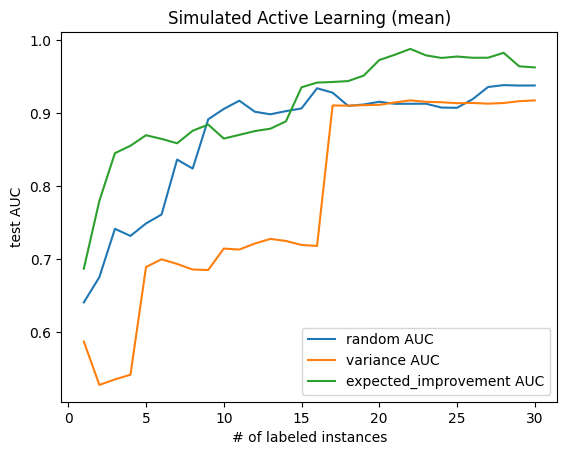

In [4]:
def simulate_active_learning():
    criteria = ['random', 'variance', 'expected_improvement']
    aucs = {criterion: [] for criterion in criteria}
    
    for criterion in criteria:
        for _ in range(1): #change the 1 to 5
            train_X, test_X, train_y, test_y = get_data()
            labeled_indices, unlabeled_indices = initialize_labeled_indices(train_y)
            model = LogisticRegression()
            criterion_aucs = []
            
            for num in range(1, 31):#change the 31 to 501
                model.fit(train_X[labeled_indices], train_y[labeled_indices])
                
                predict = model.predict_proba(test_X)[:, 1]
                auc = roc_auc_score(test_y, predict)
                criterion_aucs.append(auc)
                
                labeled_indices, unlabeled_indices = label_next_instance(train_X, train_y, labeled_indices, unlabeled_indices, model, criterion)
            
            aucs[criterion].append(criterion_aucs)
        
        #get the mean auc for each criterion and plot 
        mean_auc = np.mean(aucs[criterion], axis=0)
        plt.plot(range(1, 31), mean_auc, label=f'{criterion} AUC') #change the 31 to 501

    #for the plot
    plt.xlabel('# of labeled instances')
    plt.ylabel('test AUC')
    plt.title('Simulated Active Learning (mean)')
    plt.legend()
    plt.show()
simulate_active_learning()
#it takes about 202 minutes on my computer to run this simulation, I don't know how long it will take yours but if it doesn't immediately crash then it will work!


### Writing prompt 2: Discuss the pros and cons of both active learning methods based on how they affect performance (AUC) (1-3 sentences).

The pros of using variance to simulate active learning gives you a high AUC for small numbers of instances needing to be labeled and generally it is much faster that using expected_improvement. The con of this method is that as we have more data where we will need to label instances from unlabeled instances the worst this method performs. The pro of using expected_improvement is that it generally out performs the variance method for any number of instances. It does exceptionally well with larger numbers of data. The con is that it takes longer to compute and at specific values of unlabeled instnaces it does just as well or worse than the variance method. It is not clear why this happens or what values are the sweet spots for both methods. 

## Load in a second dataset

Generate a second random dataset by calling the supplied get_data_2 function.

In [5]:
def get_data_2():

    from sklearn.datasets import make_classification
    X , y = make_classification( n_samples=400 , n_classes=4, n_informative=20, n_features=50, n_redundant=0, n_clusters_per_class=1, class_sep=1. )

    ##Get train/test split
    train_indices , test_indices = train_test_split( np.arange( X.shape[ 0 ] ) , train_size=100 )

    train_X = X[ train_indices , : ]
    train_y = y[ train_indices ]
    test_X = X[ test_indices , : ]
    test_y = y[ test_indices ]

    return train_X , test_X , train_y , test_y


## Compare the time taken by each criteria for dataset 2

Re-run the time analysis from above on dataset_2 which you can get by calling the get_data_2 function below.

This time, use a LogisticRegression model with default parameters and max_iter set to 5000.

In [6]:
train_X, test_X, train_y, test_y = get_data_2()

labeled_indices, unlabeled_indices = initialize_labeled_indices(train_y)

criteria = ['random','variance', 'expected_improvement']
for criterion in criteria: 
    start = time.time()
    model = LogisticRegression(max_iter=5000)
    model.fit(train_X[labeled_indices], train_y[labeled_indices])
    next_instance_index = label_next_instance(train_X, train_y,  labeled_indices,  unlabeled_indices, model, criterion)
    end= time.time()
    print(f"Time taken for {criterion} is {end-start} seconds") 







Time taken for random is 0.008590936660766602 seconds
Time taken for variance is 0.028847932815551758 seconds
Time taken for expected_improvement is 2.7750298976898193 seconds


## Graph the test accuracy over number of instances labeled for each of the 3 criteria

Repeat the analysis from above graphing the performance over the number of labels.  This time, generate a new random dataset for each restart by calling get_data_2.

This time use accuracy instead of AUC!

This time, use a LogisticRegression model with default parameters and max_iter set to 5000.

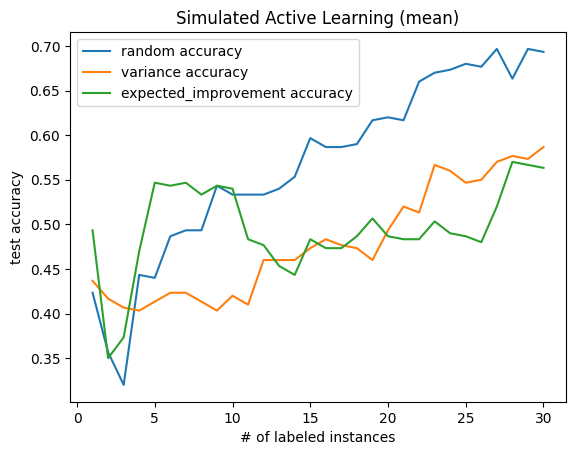

In [ ]:
def simulate_active_learning():
    criteria = ['random', 'variance', 'expected_improvement']
    accuracies = {criterion: [] for criterion in criteria}
    
    for criterion in criteria:
        for _ in range(1): #change the 1 to 5
            train_X, test_X, train_y, test_y = get_data_2() #generate data from get_data_2() 
            labeled_indices, unlabeled_indices = initialize_labeled_indices(train_y)
            model = LogisticRegression(max_iter= 5000) #LogReg with default params and max_iter= 5000
            criterion_accuracy = []
            
            for num in range(1, 31):#change the 31 to 501
                model.fit(train_X[labeled_indices], train_y[labeled_indices])
                
                predict = model.predict(test_X)
                accuracy = accuracy_score(test_y, predict) #changed from auc to meausre using accuracy 
                criterion_accuracy.append(accuracy)
                
                labeled_indices, unlabeled_indices = label_next_instance(train_X, train_y, labeled_indices, unlabeled_indices, model, criterion)
            
            accuracies[criterion].append(criterion_accuracy)
        
        #get mean accuracy for each criterion
        mean_accuracy = np.mean(accuracies[criterion], axis=0)
        plt.plot(range(1, 31), mean_accuracy, label=f'{criterion} accuracy') #change the 31 to 501

    #for the plot
    plt.xlabel('# of labeled instances')
    plt.ylabel('test accuracy')
    plt.title('Simulated Active Learning (mean)')
    plt.legend()
    plt.show()
simulate_active_learning()
#it takes about 202 minutes on my computer to run this simulation, I don't know how long it will take yours but if it doesn't immediately crash then it will work!


### Writing prompt 3: Which of the 2 methods would you use to solve this problem?  

Honestly neither of these methods has a good accuracy. It seems like they are no better than random guessing, but if I had to choose I would use variance for this size of data set. If is faster than the other method and its accuracy doesn't change that much compared to expected_improvement. 

### Writing prompt 4: Which of the 2 active learning methods would you use if you had a dataset with 6 thousand training instances in it (instead of 100-200 like we've had)?

If we had a dataset with that many instances I am definitely choosing expected_improvement because the variance will eventually normalize so it will have a hard time being accurate with that much data. Additionally, expected_improvement seems to do better when there are a larger number of instances in the dataset to work with. It will take much more time to compute but that trade off is acceptable for getting the labeling correct or more correct than it otherwise would have been.